In [3]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
from scipy.stats import lognorm
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name in {"notebooks", "physics"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

CWD: c:\Users\reymo\quant-portfolio


<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:55: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:55: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\reymo\AppData\Local\Temp\ipykernel_32288\1422953511.py:45: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  label='P-Measure (Drift = $\mu$)', color='red', linewidth=2)
C:\Users\reymo\AppData\Local\Temp\ipykernel_32288\1422953511.py:55: SyntaxWarning: "\p" is an invalid esca

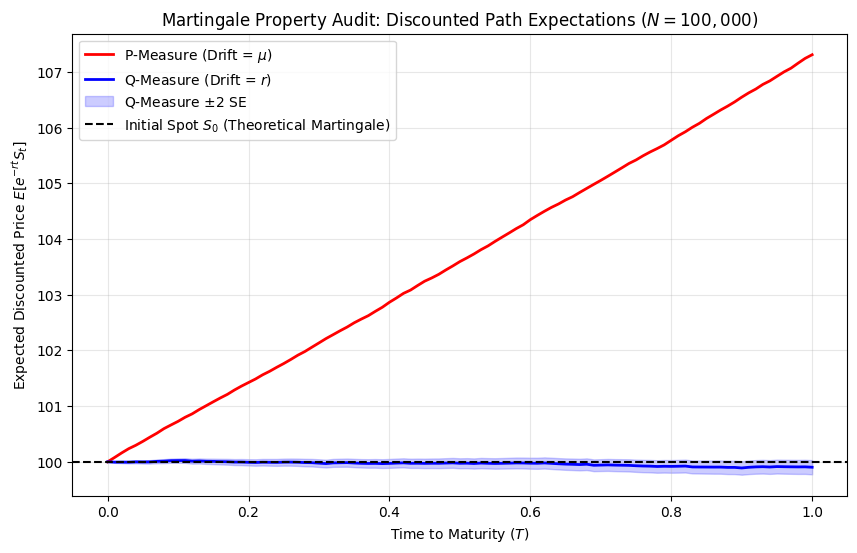

Q-Measure Terminal Martingale Error: -0.0971
Terminal Standard Error: 0.0638


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.physics.martingale_test import MartingaleAuditor

# 1. Vectorized GBM Simulator
def gbm_simulator(S0, T, n_paths, drift, vol, n_steps=100):
    dt = T / n_steps
    time_grid = np.linspace(0, T, n_steps + 1)
    
    # Vectorized path generation
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, n_steps))
    W = np.concatenate((np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)), axis=1)
    
    paths = S0 * np.exp((drift - 0.5 * vol**2) * time_grid + vol * W)
    return paths, time_grid

# 2. Setup parameters
S0 = 100.0
r = 0.05
mu = 0.12 # Real-world drift
vol = 0.20
T = 1.0
n_paths = 100000 
n_steps = 100

auditor = MartingaleAuditor()

# 3. Run Audit for P-Measure (Real World)
results_P = auditor.run_test(
    simulator=gbm_simulator, S0=S0, r=r, T=T, n_paths=n_paths, 
    drift=mu, vol=vol, n_steps=n_steps
)

# 4. Run Audit for Q-Measure (Risk Neutral)
results_Q = auditor.run_test(
    simulator=gbm_simulator, S0=S0, r=r, T=T, n_paths=n_paths, 
    drift=r, vol=vol, n_steps=n_steps
)

# 5. Visualization
plt.figure(figsize=(10, 6))

# Plot P-Measure Expectation
plt.plot(results_P['time_grid'], results_P['expected_values'], 
         label='P-Measure (Drift = $\mu$)', color='red', linewidth=2)

# Plot Q-Measure Expectation with +/- 2 Standard Errors
plt.plot(results_Q['time_grid'], results_Q['expected_values'], 
         label='Q-Measure (Drift = $r$)', color='blue', linewidth=2)

plt.fill_between(
    results_Q['time_grid'], 
    results_Q['expected_values'] - 2 * results_Q['std_errors'],
    results_Q['expected_values'] + 2 * results_Q['std_errors'],
    color='blue', alpha=0.2, label='Q-Measure $\pm 2$ SE'
)

plt.axhline(S0, color='black', linestyle='--', label='Initial Spot $S_0$ (Theoretical Martingale)')

plt.title('Martingale Property Audit: Discounted Path Expectations ($N=100,000$)')
plt.xlabel('Time to Maturity ($T$)')
plt.ylabel('Expected Discounted Price $E[e^{-rt}S_t]$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final terminal output check
final_error_Q = results_Q['martingale_errors'][-1]
final_se_Q = results_Q['std_errors'][-1]
print(f"Q-Measure Terminal Martingale Error: {final_error_Q:.4f}")
print(f"Terminal Standard Error: {final_se_Q:.4f}")